In [1]:
# =========================================================
# 1️⃣ IMPORTS
# =========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pmdarima import auto_arima
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import warnings, os
warnings.filterwarnings("ignore")


# =========================================================
# 2️⃣ LOAD DATA
# =========================================================

BASE_DIR = os.getcwd()
CSV_PATH = os.path.join(BASE_DIR, "usage_stats.csv")
OUTPUT_DIR = os.path.join(BASE_DIR, "forecast", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"]).set_index("timestamp").sort_index()



In [2]:
# =========================================================
# 3️⃣ CLEANING 00:00–07:00 AND ADD FEATURES
# =========================================================
print("🧹 Cleaning inactive hours (00:00–07:00)...")
df = df.between_time("07:00", "23:59")

# Remove days with low total activity
daily_sum = df["people_count"].resample("D").sum()
active_days = daily_sum[daily_sum > 5].index
df = df[df.index.normalize().isin(active_days)]

# Add time-based features for SARIMAX
df["hour"] = df.index.hour
df["minute"] = df.index.minute
df["time_sin"] = np.sin(2 * np.pi * (df["hour"]*60 + df["minute"]) / (24*60))
df["time_cos"] = np.cos(2 * np.pi * (df["hour"]*60 + df["minute"]) / (24*60))
df["day_of_week"] = df.index.dayofweek
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

print(f"✅ Cleaned rows: {len(df)} | Range: {df.index.min()} → {df.index.max()}")



🧹 Cleaning inactive hours (00:00–07:00)...
✅ Cleaned rows: 1404 | Range: 2025-09-11 13:46:02 → 2025-10-09 19:41:21


In [3]:
# # =========================================================
# # 🔁 3.5 AUGMENT DATA (สร้างข้อมูลย้อนหลังจำลอง)
# # =========================================================
# print("📈 Generating synthetic past weeks to enrich time series...")

# # กำหนดจำนวนสัปดาห์ที่ต้องการจำลองเพิ่ม
# weeks_to_add = 3  # คุณปรับได้ เช่น 3 = ย้อนหลัง 3 สัปดาห์

# # เก็บข้อมูลจริงไว้ก่อน
# df_original = df.copy()

# # list สำหรับเก็บข้อมูลจำลอง
# synthetic_dfs = []

# for i in range(1, weeks_to_add + 1):
#     # ขยับเวลาย้อนหลังทีละสัปดาห์
#     df_clone = df_original.copy()
#     df_clone.index = df_clone.index - pd.to_timedelta(7 * i, unit="D")
    
#     # เพิ่ม noise เล็กน้อยให้ค่าดูไม่เหมือนเดิมเป๊ะ
#     noise_factor = np.random.uniform(0.9, 1.1)
#     if np.random.rand() < 0.3:  # 30% ของสัปดาห์
#         df_clone["people_count"] *= np.random.uniform(0.6, 0.85)
#     df_clone["people_count"] = (df_clone["people_count"] * noise_factor).clip(lower=0)
#     df_clone["table_used"] = (df_clone["table_used"] * np.random.uniform(0.9, 1.1)).clip(lower=0)
#     df_clone["beanbag_used"] = (df_clone["beanbag_used"] * np.random.uniform(0.9, 1.1)).clip(lower=0)
    
#     synthetic_dfs.append(df_clone)

# # รวมทั้งหมดเข้ากับข้อมูลจริง
# df = pd.concat(synthetic_dfs + [df_original]).sort_index()
# df = df[~df.index.duplicated(keep="first")]  # กันซ้ำ

# print(f"✅ Data expanded: {len(df_original)} → {len(df)} rows")
# print(f"🗓️ Range: {df.index.min()} → {df.index.max()}")



🔎 Exploratory Data Analysis...



,people_count,table_used,table_total,beanbag_used,beanbag_total,hour,minute,time_sin,time_cos,day_of_week,is_weekend
count,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000,1404.000000
mean,3.320513,4.859687,7.686610,0.618234,5.165954,15.524929,29.285613,-0.454915,-0.246245,2.185185,0.071225
std,3.235778,2.371029,1.926317,0.995132,2.228298,4.204682,17.403567,0.550281,0.655841,1.436678,0.257292
min,0.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,1.000000,3.000000,7.000000,0.000000,4.000000,13.000000,14.000000,-0.915749,-0.829038,1.000000,0.000000
50%,3.000000,5.000000,8.000000,0.000000,5.000000,16.000000,29.000000,-0.639439,-0.426569,3.000000,0.000000
75%,5.000000,7.000000,9.000000,1.000000,7.000000,19.000000,44.000000,-0.151045,0.271440,3.000000,0.000000
max,17.000000,13.000000,13.000000,6.000000,14.000000,23.000000,59.000000,0.965926,0.999914,5.000000,1.000000



Missing values:
people_count     0
table_used       0
table_total      0
beanbag_used     0
beanbag_total    0
filename         0
hour             0
minute           0
time_sin         0
time_cos         0
day_of_week      0
is_weekend       0
dtype: int64

Detected 32 outliers in people_count.


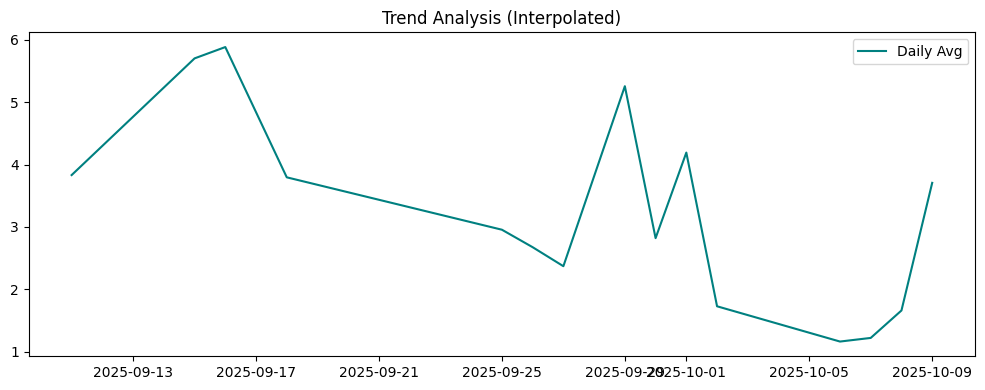

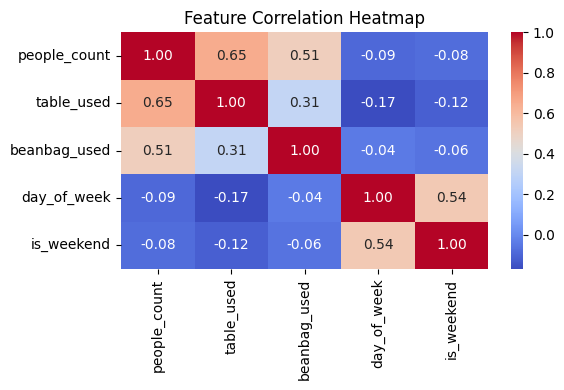

In [4]:
# =========================================================
# 4️⃣ EDA
# =========================================================
print("\n🔎 Exploratory Data Analysis...\n")

# Descriptive stats
display(df.describe())

# Missing values
print("\nMissing values:")
print(df.isna().sum())

# Outlier detection (IQR method for people_count)
Q1, Q3 = df["people_count"].quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = df[(df["people_count"] < (Q1 - 1.5 * IQR)) | (df["people_count"] > (Q3 + 1.5 * IQR))]
print(f"\nDetected {len(outliers)} outliers in people_count.")

# Plot trend (interpolated)
plt.figure(figsize=(10,4))
plt.plot(df["people_count"].resample("D").mean().interpolate(), color="teal", label="Daily Avg")
plt.title("Trend Analysis (Interpolated)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/trend_analysis.png")
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,4))
sns.heatmap(df[["people_count", "table_used", "beanbag_used", "day_of_week", "is_weekend"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_correlation.png")
plt.show()


In [5]:
# =========================================================
# 5️⃣ STATIONARITY TEST (ADF)
# =========================================================
print("\n⚙️ Stationarity Check (ADF Test)")
adf_result = adfuller(df["people_count"])
print(f"ADF Statistic: {adf_result[0]:.3f}")
print(f"p-value: {adf_result[1]:.5f}")
if adf_result[1] < 0.05:
    print("✅ Stationary")
else:
    print("⚠️ Non-stationary — will apply differencing automatically")




⚙️ Stationarity Check (ADF Test)
ADF Statistic: -8.525
p-value: 0.00000
✅ Stationary


In [6]:
# =========================================================
# 6️⃣ FORECASTING FUNCTION
# =========================================================
def run_forecast(freq, m):
    y = df["people_count"].resample(freq).mean().fillna(0)
    exog = df[["table_used", "beanbag_used", "day_of_week", "is_weekend", "time_sin", "time_cos"]]

    split = int(len(y)*0.8)
    train, test = y[:split], y[split:]
    exog_train, exog_test = exog[:split], exog[split:]
    
    results = []

    # ARIMA
    arima = auto_arima(train, seasonal=False, trace=False, error_action="ignore")
    f_arima = arima.predict(len(test))
    results.append({"Model": "ARIMA", "RMSE": np.sqrt(mean_squared_error(test, f_arima)), "MAPE": mean_absolute_percentage_error(test, f_arima)})

    # SARIMA
    sarima = auto_arima(train, seasonal=True, m=144, trace=False, error_action="ignore")
    f_sarima = sarima.predict(len(test))
    results.append({"Model": "SARIMA", "RMSE": np.sqrt(mean_squared_error(test, f_sarima)), "MAPE": mean_absolute_percentage_error(test, f_sarima)})

    # SARIMAX
    sarimax = SARIMAX(train, exog=exog_train, order=(1,1,1), seasonal_order=(1,1,1,m), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
    f_sarimax = sarimax.predict(start=len(train), end=len(train)+len(test)-1, exog=exog_test)
    results.append({"Model": "SARIMAX", "RMSE": np.sqrt(mean_squared_error(test, f_sarimax)), "MAPE": mean_absolute_percentage_error(test, f_sarimax)})

    # Plot comparison
    plt.figure(figsize=(12,4))
    plt.plot(train.index, train, color="gray", label="Train")
    plt.plot(test.index, test, color="blue", label="Actual")
    plt.plot(test.index, f_arima, color="red", label="ARIMA")
    plt.plot(test.index, f_sarima, color="green", label="SARIMA")
    plt.plot(test.index, f_sarimax, color="orange", label="SARIMAX")
    plt.legend(); plt.title(f"Model Comparison - {freq}")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/forecast_comparison_{freq}.png")
    plt.show()

    df_out = pd.DataFrame(results)
    df_out.to_csv(f"{OUTPUT_DIR}/metrics_{freq}.csv", index=False)
    display(df_out)
    return df_out



In [7]:
# =========================================================
# 7️⃣ RUN FORECASTS (10-Minute + Daily)
# =========================================================
print("\n🚀 Starting Forecasting...\n")
metrics_10T = run_forecast("10T", 6)
metrics_D = run_forecast("D", 7)

all_metrics = pd.concat([
    metrics_10T.assign(Frequency="10-Minute"),
    metrics_D.assign(Frequency="Daily")
])
all_metrics.to_csv(f"{OUTPUT_DIR}/model_performance.csv", index=False)

best_models = all_metrics.loc[all_metrics.groupby("Frequency")["RMSE"].idxmin()]
best_models.to_csv(f"{OUTPUT_DIR}/best_model_summary.csv", index=False)
display(best_models)




🚀 Starting Forecasting...



MemoryError: Unable to allocate 529. MiB for an array with shape (146, 146, 3255) and data type float64


🔮 Generating 48-hour forecast...


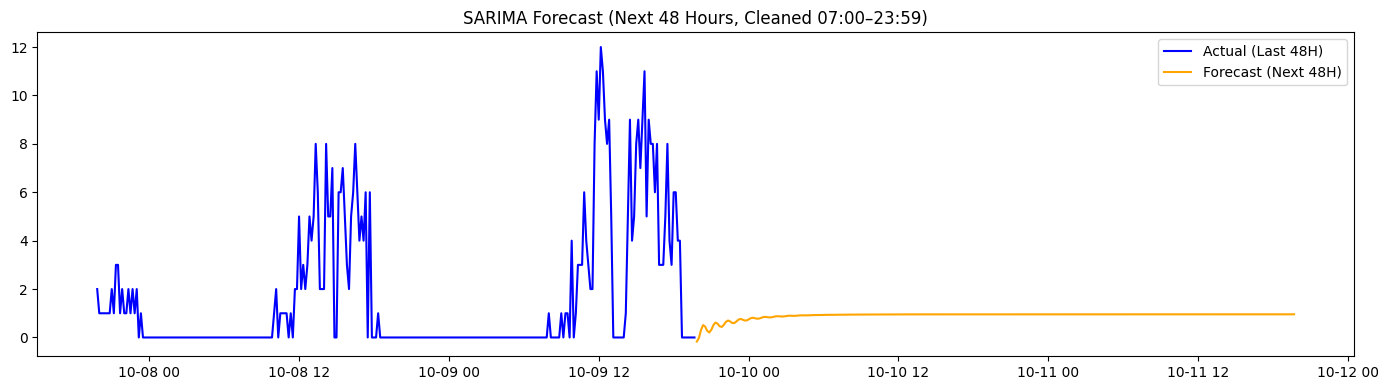

✅ Forecast completed and saved in outputs/


In [ ]:
print("\n🔮 Generating 48-hour forecast...")

# ใช้เฉพาะคอลัมน์ที่เป็นตัวเลข
numeric_cols = df.select_dtypes(include=[np.number]).columns
latest = df[numeric_cols].resample("10T").mean().fillna(0)
exog_latest = latest[["table_used", "beanbag_used", "day_of_week", "is_weekend"]]

sarima = auto_arima(latest["people_count"], seasonal=True, m=6, trace=False, error_action="ignore")

fcast_len = 48 * 6  # 48 ชั่วโมง = 288 จุด (10 นาที)
sarima_forecast = sarima.predict(fcast_len)

future_index = pd.date_range(df.index.max(), periods=fcast_len + 1, freq="10T")[1:]

plt.figure(figsize=(14, 4))
plt.plot(latest.index[-48*6:], latest["people_count"][-48*6:], color="blue", label="Actual (Last 48H)")
plt.plot(future_index, sarima_forecast, color="orange", label="Forecast (Next 48H)")
plt.title("SARIMA Forecast (Next 48 Hours, Cleaned 07:00–23:59)")
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/forecast_next_48h.png")
plt.show()

print("✅ Forecast completed and saved in outputs/")
